<a href="https://colab.research.google.com/github/minhaz-engg/Time-Series-try/blob/main/trying_neuralforecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install mlforecast

In [8]:
import pandas as pd
import lightgbm as lgb
from xgboost import XGBRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mse, mae, mape

# 1. Ingesting an Empirical Benchmark Dataset
# We dynamically pull the ETTh1 dataset, a rigorous multivariate time-series benchmark.
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
print("Downloading empirical benchmark data...")
df_raw = pd.read_csv(url)

# Reformatting to adhere to the Nixtlaverse structural paradigm (unique_id, ds, y)
df = df_raw.rename(columns={'date': 'ds', 'OT': 'y'})
df['unique_id'] = 'Transformer_Alpha'
df['ds'] = pd.to_datetime(df['ds'])

# To maintain computational equilibrium during demonstration,
# we isolate a contiguous block of the most recent 3,000 hourly observations.
df = df.tail(3000).reset_index(drop=True)

# 2. Architecting the MLForecast Paradigm
models = [
    lgb.LGBMRegressor(random_state=42, verbosity=-1, n_estimators=150),
    XGBRegressor(random_state=42, n_estimators=150, objective='reg:squarederror')
]

# Extracting the nomenclature of our exogenous features (the electrical loads)
exogenous_features = [col for col in df.columns if col not in ['unique_id', 'ds', 'y']]

forecast_engine = MLForecast(
    models=models,
    freq='h', # The ETTh1 dataset is recorded at an hourly frequency
    lags=[1, 24, 168], # Capturing immediate, daily, and weekly autoregressive signals
    lag_transforms={
        24: [RollingMean(window_size=24)],
        168: [RollingMean(window_size=24)]
    },
    date_features=['hour', 'dayofweek'],
    target_transforms=[Differences([1])] # Enforcing stationarity
)

# 3. Strict Temporal Validation Partitioning
horizon = 48 # Projecting the subsequent 48 hours
df_train = df.iloc[:-horizon]
df_test = df.iloc[-horizon:]

# Isolating the future values of our exogenous covariates.
# (Note: In production forecasting, these are often planned interventions or secondary forecasts).
X_df = df_test[['unique_id', 'ds'] + exogenous_features]

# 4. Algorithmic Optimization and Inference
print("Commencing model fitting on empirical data...")
forecast_engine.fit(
    df_train,
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    static_features=[]
)

print("Executing multivariate projection...")
predictions = forecast_engine.predict(h=horizon, X_df=X_df)

# 5. Quantification of Veracity
results = predictions.merge(df_test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])

evaluation_metrics = evaluate(
    df=results,
    metrics=[mse, mae, mape],
    models=['LGBMRegressor', 'XGBRegressor']
)

print("\nEmpirical Evaluation Metrics:")
print(evaluation_metrics.groupby('metric').mean(numeric_only=True))

Commencing model fitting on empirical data...
Executing multivariate projection...

Empirical Evaluation Metrics:
        LGBMRegressor  XGBRegressor
metric                             
mae          0.867629      1.246822
mape         0.085887      0.121628
mse          1.176037      2.622735



Initiating advanced visual diagnostics...


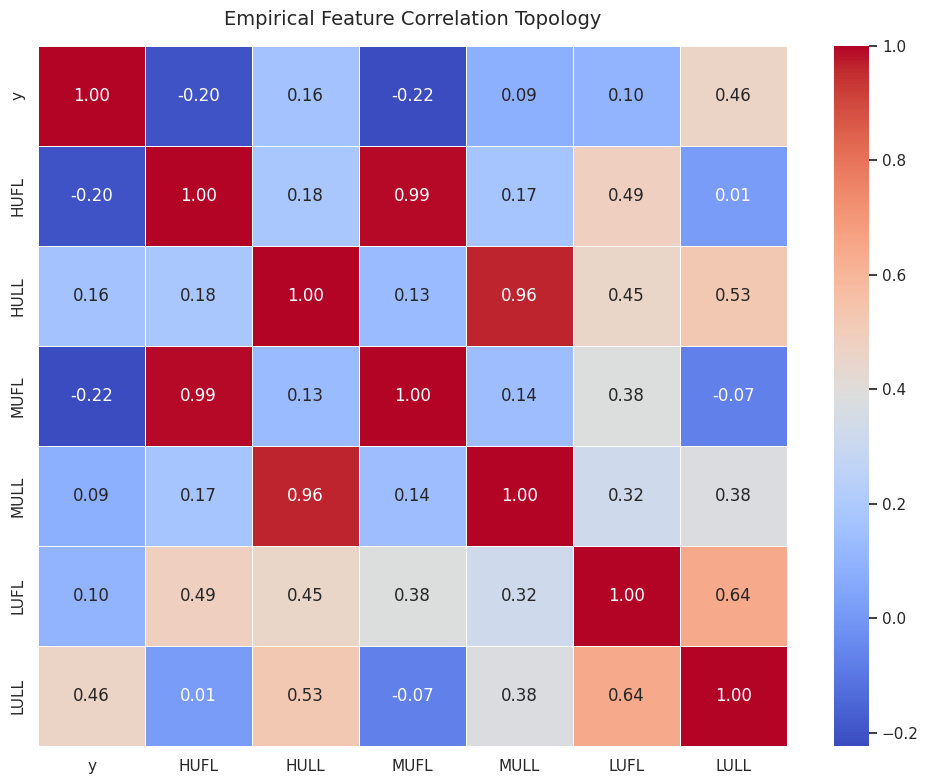

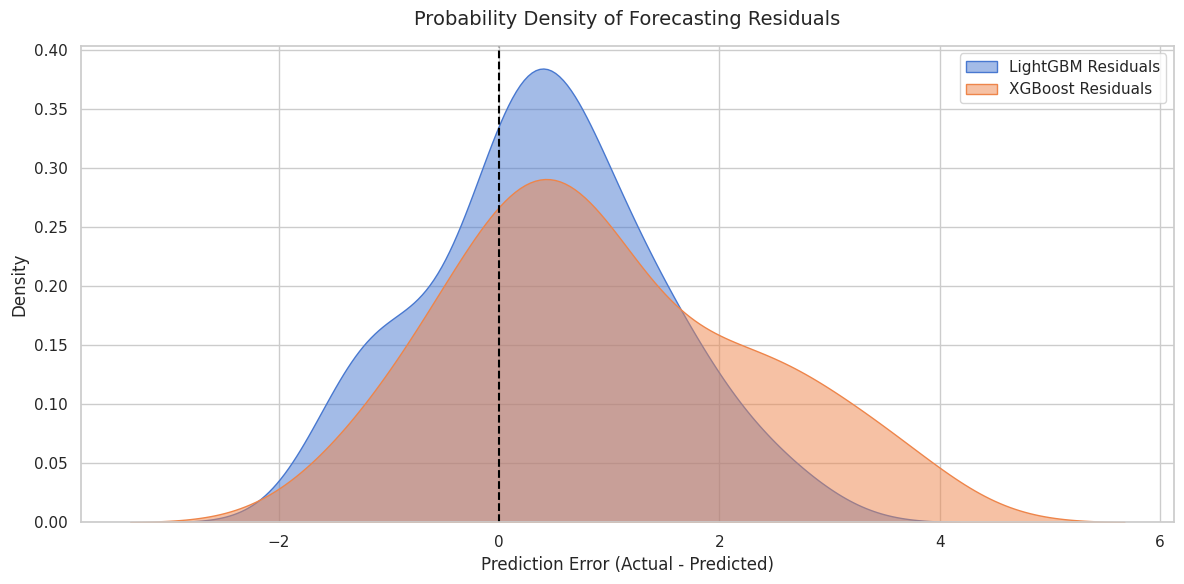

/tmp/ipykernel_10071/3916632019.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


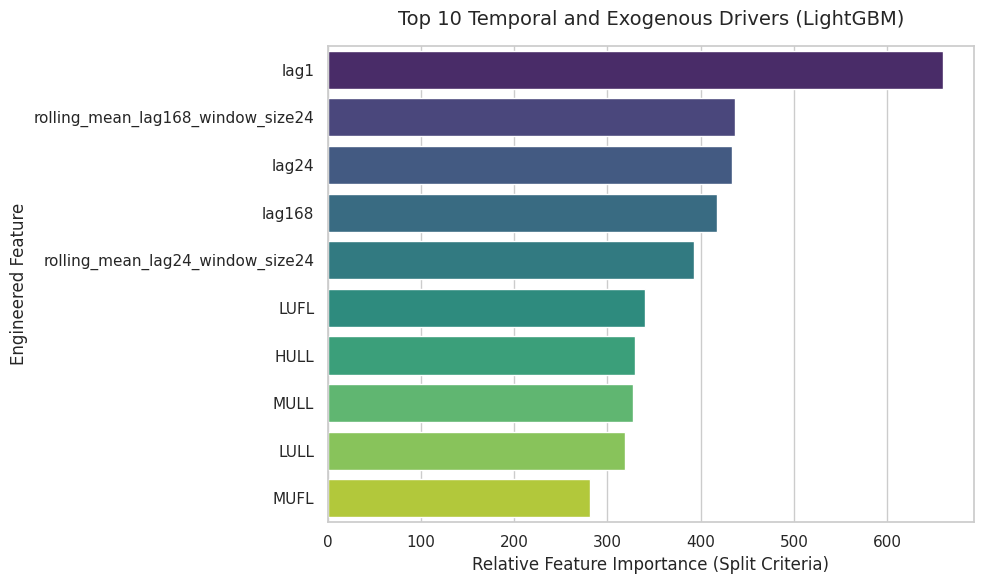

Visual orchestration complete. 4 high-resolution diagnostic plots exported to local directory.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

# ==============================================================================
# 6. COMPREHENSIVE VISUAL DIAGNOSTICS & SYNTHESIS
# ==============================================================================
print("\nInitiating advanced visual diagnostics...")

# Set a sophisticated, high-contrast aesthetic for all seaborn plots
sns.set_theme(style="whitegrid", palette="muted")

# ------------------------------------------------------------------------------
# Visualization A: Multivariate Correlation Matrix
# Elucidating the underlying orthogonal relationships between the target (y)
# and the exogenous electrical covariates prior to modeling.
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
# We compute the Pearson correlation coefficient across the empirical dataset
correlation_matrix = df[['y'] + exogenous_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Empirical Feature Correlation Topology', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('diagnostic_1_correlation_matrix.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# Visualization B: High-Fidelity Forecast Trajectory (Nixtla Native)
# Juxtaposing the terminal sequence of the training data with our bifurcated projections.
# ------------------------------------------------------------------------------
# We isolate the most recent 120 observations to prevent historical obfuscation
historical_context = df_train.tail(120)

fig_trajectory = plot_series(
    df=historical_context,
    forecasts_df=predictions,
    models=['LGBMRegressor', 'XGBRegressor'],
    palette='Set1'
)
# plot_series returns a matplotlib figure which we can save directly
fig_trajectory.savefig('diagnostic_2_forecast_trajectory.png', dpi=300, bbox_inches='tight')

# ------------------------------------------------------------------------------
# Visualization C: Algorithmic Residual Distribution
# Quantifying the variance and central tendency of our prediction errors.
# A robust model should exhibit a Gaussian distribution of residuals centered near zero.
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Calculating deterministic error vectors
results['LGBM_Residuals'] = results['y'] - results['LGBMRegressor']
results['XGB_Residuals'] = results['y'] - results['XGBRegressor']

sns.kdeplot(data=results['LGBM_Residuals'], label='LightGBM Residuals', fill=True, alpha=0.5)
sns.kdeplot(data=results['XGB_Residuals'], label='XGBoost Residuals', fill=True, alpha=0.5)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Probability Density of Forecasting Residuals', fontsize=14, pad=15)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('diagnostic_3_residual_density.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# Visualization D: Gradient Boosting Feature Importance
# Demystifying the heuristic weightings assigned by the LightGBM architecture.
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Extracting the underlying trained LightGBM model from the MLForecast engine
lgbm_model = forecast_engine.models_['LGBMRegressor']

# Formatting the importance array into a manipulable dataframe
importance_df = pd.DataFrame({
    'Feature': forecast_engine.ts.features_order_,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10) # Isolating top 10 vectors

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Temporal and Exogenous Drivers (LightGBM)', fontsize=14, pad=15)
plt.xlabel('Relative Feature Importance (Split Criteria)')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.savefig('diagnostic_4_feature_importance.png', dpi=300)
plt.show()

print("Visual orchestration complete. 4 high-resolution diagnostic plots exported to local directory.")


Architecting bespoke time-series line plot...
Bespoke time-series plot successfully synthesized and saved as 'diagnostic_5_bespoke_timeseries.png'.


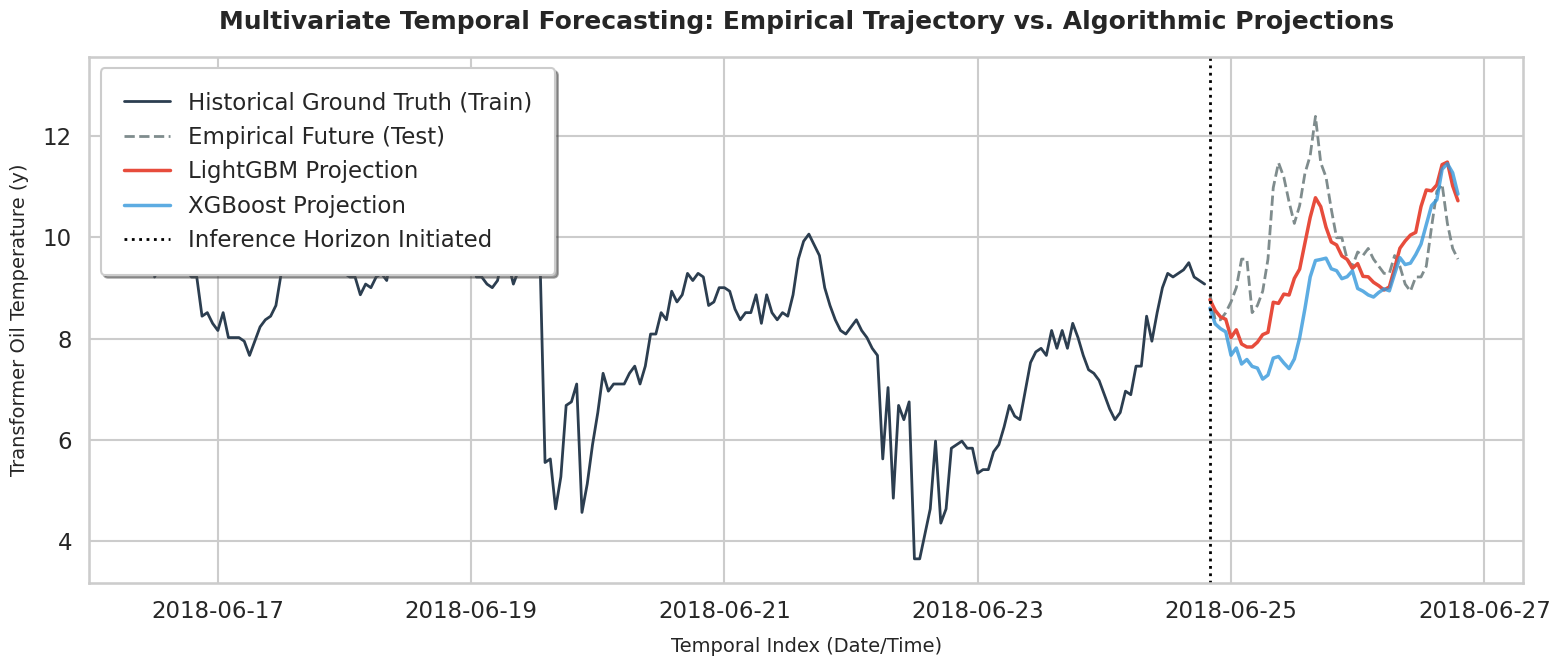

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nArchitecting bespoke time-series line plot...")

# 1. Aesthetic Configuration
# Establishing a highly legible, rigorous visual paradigm
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(16, 7))

# 2. Temporal Windowing
# We isolate a contiguous block of historical data (e.g., the final 200 hours of training)
# to provide salient context without obfuscating the forecast horizon.
history_window = df_train.tail(200)

# 3. Geometric Rendering of the Ground Truth
# Plotting the empirical historical trajectory
plt.plot(history_window['ds'], history_window['y'],
         label='Historical Ground Truth (Train)',
         color='#2c3e50', linewidth=2)

# Plotting the empirical future trajectory (what actually happened)
plt.plot(df_test['ds'], df_test['y'],
         label='Empirical Future (Test)',
         color='#7f8c8d', linewidth=2, linestyle='--')

# 4. Superimposing Algorithmic Projections
# Juxtaposing the LightGBM and XGBoost forecasted trajectories
plt.plot(predictions['ds'], predictions['LGBMRegressor'],
         label='LightGBM Projection',
         color='#e74c3c', linewidth=2.5)

plt.plot(predictions['ds'], predictions['XGBRegressor'],
         label='XGBoost Projection',
         color='#3498db', linewidth=2.5, alpha=0.8)

# 5. Typographic and Structural Refinements
plt.title('Multivariate Temporal Forecasting: Empirical Trajectory vs. Algorithmic Projections',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Temporal Index (Date/Time)', fontsize=14, labelpad=10)
plt.ylabel('Transformer Oil Temperature (y)', fontsize=14, labelpad=10)

# Delineating the precise point of inference
forecast_start = df_test['ds'].iloc[0]
plt.axvline(x=forecast_start, color='black', linestyle=':', linewidth=2,
            label='Inference Horizon Initiated')

plt.legend(loc='upper left', frameon=True, shadow=True, borderpad=1)
plt.tight_layout()

# 6. Artifact Export
plt.savefig('diagnostic_5_bespoke_timeseries.png', dpi=300)
print("Bespoke time-series plot successfully synthesized and saved as 'diagnostic_5_bespoke_timeseries.png'.")
plt.show()